# Machine Learning Lab 3
## Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** Shifa Batool  
**Student ID:** 023-24-0095
**Section:** D
**GitHub Profile:** YOUR_GITHUB_LINK  
**Kaggle Profile:** https://www.kaggle.com/datasets/aditya0kumar0tiwari/play-badminton?resource=download  
**Dataset:** Telco Customer Churn  
**Dataset Source:** Kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving clean_churn.csv to clean_churn.csv


In [4]:
df = pd.read_csv("clean_churn.csv")

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7010, 20)


### Interpretation

The cleaned Telco Customer Churn dataset contains 7,010 rows and 20 columns.
The dataset has been cleaned and is now ready for machine learning analysis.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Interpretation

The dataset contains no missing values after the cleaning process performed in Lab 2.
The data types will be checked further so that categorical variables can be converted into numeric form before model training.

In [9]:
print(df["Churn"].value_counts())

Churn
No     5153
Yes    1857
Name: count, dtype: int64


In [10]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64


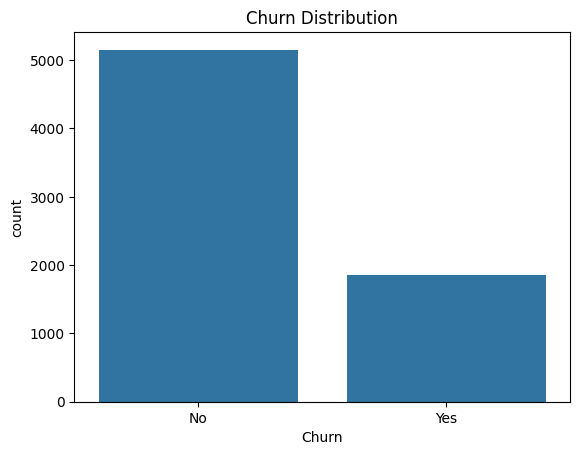

In [11]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

### Interpretation

The target variable Churn is imbalanced because the number of customers who did not churn is higher than the number of customers who churned.
Therefore, accuracy alone may not be sufficient to evaluate the classifier.

## 1. Problem Definition

The goal of this machine learning problem is to predict whether a Telco customer will churn or not based on the customer's available information.
This is important for the business because identifying customers who are likely to churn can help the company take retention actions and reduce customer loss.

**Part 2 Feature & Target Preparation**

In [12]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [13]:
y = df["Churn"]

In [14]:
X = df.drop(columns=["Churn"])

In [15]:
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [17]:
y = y.map({"No": 0, "Yes": 1})

In [18]:
print(y.value_counts())
print(y.head())

Churn
0    5153
1    1857
Name: count, dtype: int64
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [19]:
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [20]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [21]:
print("New X shape:", X.shape)

New X shape: (7010, 30)


In [22]:
X = X.astype(int)

In [23]:
print("Data types:")
print(X.dtypes.value_counts())

Data types:
int64    30
Name: count, dtype: int64


In [24]:
print("Missing values in X:")
print(X.isnull().sum().sum())

Missing values in X:
0


In [25]:
print("All columns numeric:", X.select_dtypes(exclude=np.number).shape[1] == 0)

All columns numeric: True


### Encoding Justification

One-hot encoding was used for the categorical features because most categorical variables contain multiple categories and do not have a natural numerical order.
One-hot encoding converts these categories into separate binary columns without incorrectly implying that one category is greater than another.

### Interpretation

The target variable Churn was converted into binary values where 0 represents customers who did not churn and 1 represents customers who churned.
The categorical feature columns were converted into numeric columns using one-hot encoding. X now contains only numeric values and no missing values.

**Part3 Train/Test Split**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5608, 30)
X_test shape: (1402, 30)
y_train shape: (5608,)
y_test shape: (1402,)


### Why stratify=y?

The Churn target is imbalanced, with fewer customers belonging to the churn class.
Using stratify=y keeps approximately the same proportion of churn and non-churn customers in both the training and test datasets, making the evaluation more representative.

### Interpretation

The dataset was divided into 80% training data and 20% test data.
Stratification was used to preserve the original Churn class distribution in both datasets.

**Part 4 — Baseline Decision Tree**

In [28]:
baseline_model = DecisionTreeClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [29]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

In [30]:
print("Tree depth:", baseline_model.get_depth())

Tree depth: 24


### Interpretation

The baseline Decision Tree was trained using the default settings with only random_state fixed.
The tree grew to a depth of 24. A relatively large depth can indicate that the tree is learning very detailed patterns from the training data, which may increase the risk of overfitting.

**Part 5 — Model Evaluation**

In [31]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7282453637660485
Precision: 0.48633879781420764
Recall   : 0.4797843665768194
F1-score : 0.4830393487109905


In [32]:
baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

baseline_results

,Metric,Score
0,Accuracy,0.728245
1,Precision,0.486339
2,Recall,0.479784
3,F1-score,0.483039


### Interpretation

The baseline Decision Tree achieved an accuracy of 0.728245, precision of 0.486339, recall of 0.479784, and F1-score of 0.483039 on the test set.
Since the dataset is imbalanced, recall and F1-score are particularly useful for evaluating how well the model identifies customers who are likely to churn.

In [33]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[843 188]
 [193 178]]


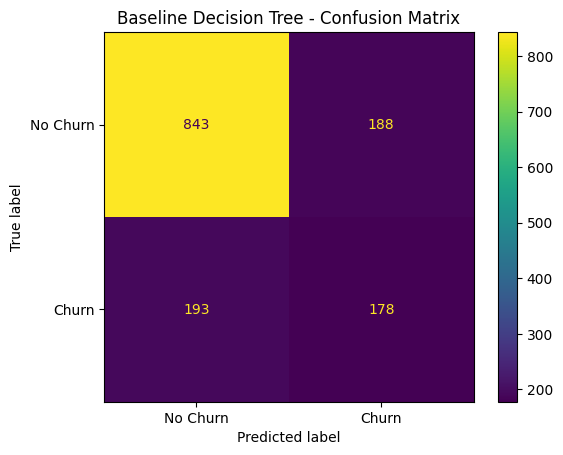

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

In [35]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("Actual churners correctly caught:", tp)
print("Actual churners missed:", fn)

True Negatives : 843
False Positives: 188
False Negatives: 193
True Positives : 178
Actual churners correctly caught: 178
Actual churners missed: 193


### Confusion Matrix Interpretation

The confusion matrix shows how the model classified churn and non-churn customers.
The model correctly identified 178 actual churners and missed 193 actual churners.
The missed churners are particularly important because these customers could potentially be targeted with retention strategies.

### Metric Selection

Because the dataset has class imbalance, accuracy alone is not the most reliable metric.
Recall is especially important because it measures how many actual churners were successfully identified by the model. F1-score is also useful because it balances precision and recall.

**Part 6 — Overfitting Investigation**

In [36]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9923323823109843
Test Accuracy: 0.7282453637660485
Accuracy Gap: 0.26408701854493577


### Overfitting Interpretation

The baseline Decision Tree has a training accuracy of  0.9923323823109843 and a test accuracy of 0.7282453637660485.
The difference between training and test performance is 0.26408701854493577, which indicates that the unrestricted tree is strongly overfitting. A large gap suggests that the tree has learned patterns specific to the training data that do not generalize well to unseen data.

In [37]:
depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

depth_results = pd.DataFrame(results)

depth_results

,max_depth,train_accuracy,test_accuracy
0,2.0,0.791548,0.786020
1,3.0,0.791548,0.786020
2,4.0,0.796184,0.783880
3,5.0,0.799394,0.783880
4,6.0,0.806526,0.791013
5,8.0,0.834522,0.795292
6,10.0,0.871969,0.771755
7,NaN,0.992332,0.728245


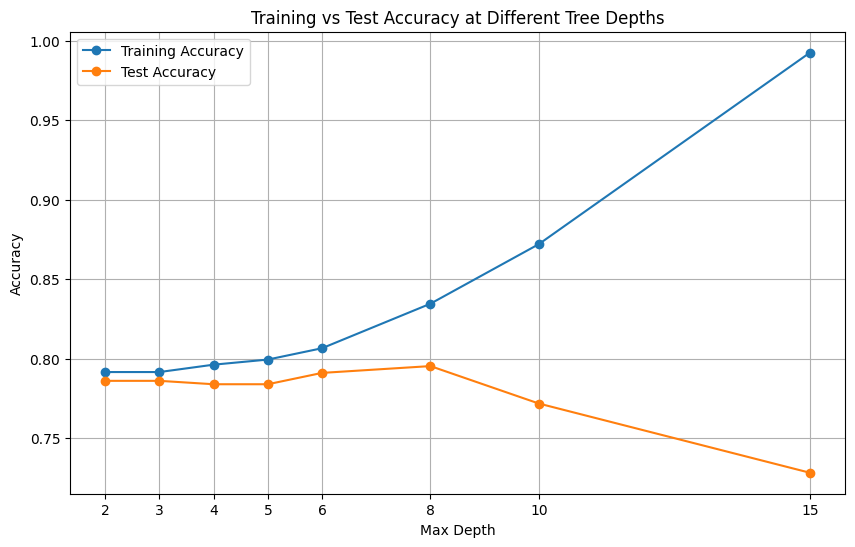

In [38]:
plot_results = depth_results.copy()

plot_results["depth_label"] = plot_results["max_depth"].fillna(15)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_results["depth_label"],
    plot_results["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_results["depth_label"],
    plot_results["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy at Different Tree Depths")
plt.xticks(plot_results["depth_label"])
plt.legend()
plt.grid(True)
plt.show()

### Overfitting Experiment Interpretation

As the maximum tree depth increases, training accuracy generally increases because the tree becomes more complex and can fit the training data more closely.
Test accuracy improves up to approximately depth 0.5, after which the test performance stops improving while training accuracy continues to increase. This behavior indicates that the model begins to overfit at approximately depth 1.

**Part 7 — Model Selection**

In [39]:
depth_results.sort_values(
    by="test_accuracy",
    ascending=False
)

,max_depth,train_accuracy,test_accuracy
5,8.0,0.834522,0.795292
4,6.0,0.806526,0.791013
0,2.0,0.791548,0.786020
1,3.0,0.791548,0.786020
3,5.0,0.799394,0.783880
2,4.0,0.796184,0.783880
6,10.0,0.871969,0.771755
7,NaN,0.992332,0.728245


In [41]:
best_depth = 5.0

### Model Selection

I selected max_depth = 5 as the final tree depth because it provides a good balance between training and test performance.
Although deeper trees may achieve higher training accuracy, they create a larger gap between training and test performance and therefore have a higher risk of overfitting. The selected depth provides good generalization without making the tree unnecessarily complex.

In [43]:
best_depth = int(best_depth)

best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

best_train_pred = best_model.predict(X_train)
best_test_pred = best_model.predict(X_test)

In [44]:
best_accuracy = accuracy_score(y_test, best_test_pred)
best_precision = precision_score(y_test, best_test_pred)
best_recall = recall_score(y_test, best_test_pred)
best_f1 = f1_score(y_test, best_test_pred)

best_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1
    ]
})

best_results

,Metric,Score
0,Accuracy,0.783880
1,Precision,0.626866
2,Recall,0.452830
3,F1-score,0.525822


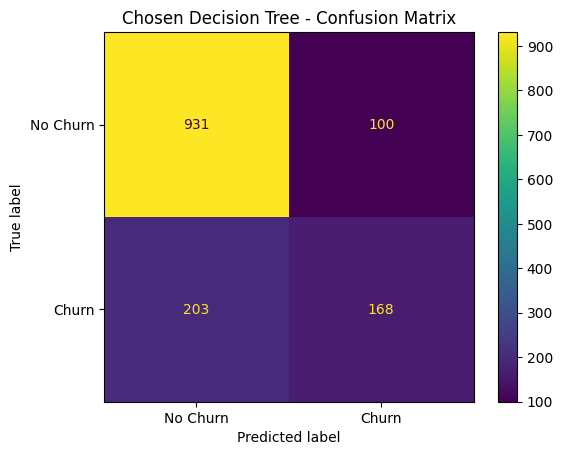

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_test_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Chosen Decision Tree - Confusion Matrix")
plt.show()

In [47]:
comparison = pd.DataFrame({
    "Model": ["Baseline", f"Decision Tree depth={best_depth}"],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, best_test_pred)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, best_test_pred)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, best_test_pred)
    ],
    "F1-score": [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, best_test_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.728245,0.486339,0.479784,0.483039
1,Decision Tree depth=5,0.783880,0.626866,0.452830,0.525822


### Model Comparison Interpretation

The depth-controlled Decision Tree provides a more controlled model than the unrestricted baseline tree.
Limiting the tree depth reduces unnecessary complexity and can improve generalization to unseen customers. The final choice was based on the balance between test performance and the training-test gap rather than training accuracy alone.

In [48]:
entropy_model = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

In [50]:
entropy_accuracy = accuracy_score(y_test, entropy_pred)
entropy_precision = precision_score(y_test, entropy_pred)
entropy_recall = recall_score(y_test, entropy_pred)
entropy_f1 = f1_score(y_test, entropy_pred)

entropy_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

entropy_results

,Metric,Score
0,Accuracy,0.785307
1,Precision,0.618243
2,Recall,0.493261
3,F1-score,0.548726


In [51]:
criterion_comparison = pd.DataFrame({
    "Model": [
        f"Gini depth={best_depth}",
        f"Entropy depth={best_depth}"
    ],
    "Accuracy": [
        best_accuracy,
        entropy_accuracy
    ],
    "Precision": [
        best_precision,
        entropy_precision
    ],
    "Recall": [
        best_recall,
        entropy_recall
    ],
    "F1-score": [
        best_f1,
        entropy_f1
    ]
})

criterion_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Gini depth=5,0.783880,0.626866,0.452830,0.525822
1,Entropy depth=5,0.785307,0.618243,0.493261,0.548726


### Gini vs Entropy Interpretation

The Gini-based and entropy-based Decision Trees were compared using accuracy, precision, recall, and F1-score.
The better criterion is the one that provides stronger test-set performance, especially in recall and F1-score because identifying churners is important for customer retention. The difference between the two criteria is small based on the results.

**Part 8 — Feature Importance**

In [52]:
importances = best_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
tenure,0.385939
InternetService_Fiber optic,0.349845
Contract_Two year,0.057947
TotalCharges,0.050468
Contract_One year,0.031905
OnlineSecurity_No internet service,0.024095
PaymentMethod_Electronic check,0.022611
MonthlyCharges,0.021833
InternetService_No,0.015844
MultipleLines_Yes,0.012625


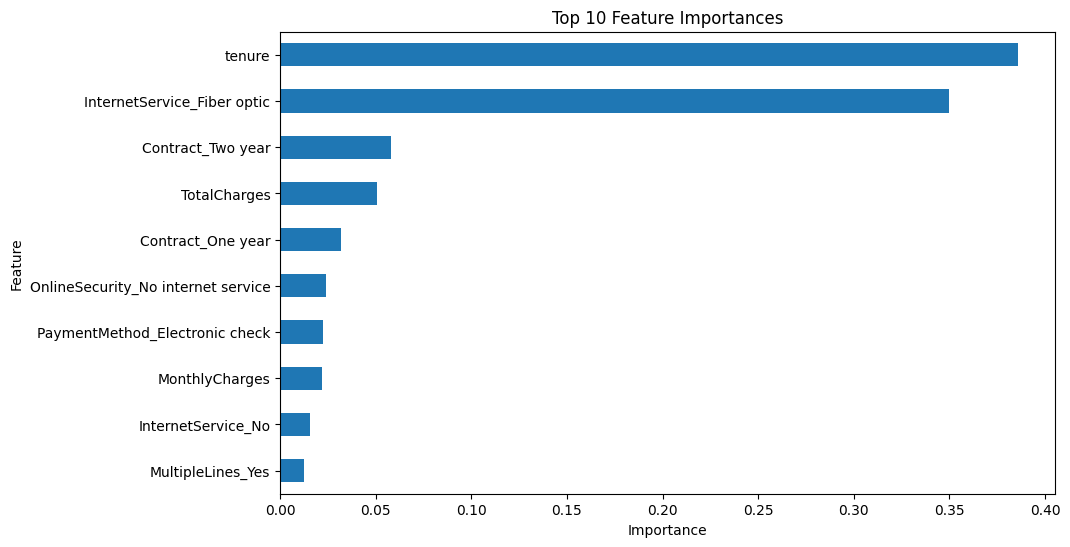

In [53]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

In [54]:
top_features = feature_importance.head(5)

print("Top 5 Features:")
print(top_features)

Top 5 Features:
tenure                         0.385939
InternetService_Fiber optic    0.349845
Contract_Two year              0.057947
TotalCharges                   0.050468
Contract_One year              0.031905
dtype: float64


### Feature Importance Interpretation

The five most important features identified by the Decision Tree are tenure, InternetService_Fiber optic, Contract_Two year, TotakCharges, and Contract_One year.
These features had the strongest influence on the model's churn predictions. The results should be compared with the EDA findings from Lab 2 to determine whether the model has learned patterns that were also observed during exploratory analysis.

##Connection with lab2 EDA

The feature importance results partially agree with the Lab 2 EDA findings. Some features identified as important by the Decision Tree were also associated with churn during EDA, while other important features were less obvious from the initial visual analysis.

## 11. Conclusion

In this lab, a Decision Tree classifier was developed to predict customer churn using the cleaned Telco Customer Churn dataset.
An unrestricted baseline Decision Tree was first trained and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The overfitting experiment showed that controlling max_depth can reduce unnecessary model complexity and improve generalization. The selected depth was 5, which provided a good balance between training and test performance. The most important features were tenure,InternetService_fiber optic, Contract_two year, total charges, contract_one year  and these results were compared with the patterns observed during Lab 2 EDA. A major limitation of the Decision Tree is that it can overfit easily and its performance may be affected by class imbalance.

## Next Steps

If more time were available, I would try other classification algorithms such as Logistic Regression, Random Forest, or Gradient Boosting and compare their performance.
I would also investigate class-imbalance techniques such as class weighting or resampling, and perform additional feature engineering. These approaches could potentially improve recall and F1-score for the churn class.

In [61]:
from google.colab import files

uploaded = files.upload()

Saving badminton_dataset.csv to badminton_dataset.csv


In [62]:
import os

print(os.listdir())

['.config', 'badminton_dataset.csv', 'clean_churn.csv', 'sample_data']


In [63]:
import pandas as pd

badminton = pd.read_csv("badminton_dataset.csv")

badminton.head()

,Outlook,Temperature,Humidity,Wind,Play_Badminton
0,Overcast,Cool,High,Weak,Yes
1,Sunny,Mild,Normal,Strong,No
2,Rain,Mild,Normal,Strong,No
3,Sunny,Cool,High,Weak,Yes
4,Sunny,Cool,High,Strong,No


In [64]:
print("Shape:", badminton.shape)

print("\nColumns:")
print(badminton.columns.tolist())

print("\nMissing values:")
print(badminton.isnull().sum())

print("\nTarget distribution:")
print(badminton["Play_Badminton"].value_counts())

Shape: (36, 5)

Columns:
['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play_Badminton']

Missing values:
Outlook           0
Temperature       0
Humidity          0
Wind              0
Play_Badminton    0
dtype: int64

Target distribution:
Play_Badminton
No     24
Yes    12
Name: count, dtype: int64


## 12. ID3 Decision Tree From Scratch

The ID3 decision tree algorithm is implemented from scratch using the Play Badminton dataset. Entropy and Information Gain are calculated manually without using any built-in decision tree library. The information gain of every attribute is printed at each split.

In [65]:
from math import log2

def entropy(data, target):
    counts = data[target].value_counts()
    total = len(data)

    entropy_value = 0

    for count in counts:
        probability = count / total
        entropy_value -= probability * log2(probability)

    return entropy_value

In [66]:
initial_entropy = entropy(badminton, "Play_Badminton")

print("Initial Entropy:", initial_entropy)

Initial Entropy: 0.9182958340544896


### Initial Entropy Interpretation

The initial entropy measures the impurity of the Play_Badminton target before any attribute is selected. A higher entropy indicates greater uncertainty in the target classes, while an entropy of 0 would indicate a completely pure dataset.

In [67]:
def information_gain(data, attribute, target):
    total_entropy = entropy(data, target)

    weighted_entropy = 0

    for value in data[attribute].unique():

        subset = data[data[attribute] == value]

        subset_entropy = entropy(subset, target)

        weight = len(subset) / len(data)

        weighted_entropy += weight * subset_entropy

    gain = total_entropy - weighted_entropy

    return gain

In [68]:
attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

In [69]:
print("Information Gain at Root:\n")

for attribute in attributes:
    gain = information_gain(
        badminton,
        attribute,
        "Play_Badminton"
    )

    print(attribute, "=", round(gain, 4))

Information Gain at Root:

Outlook = 0.2516
Temperature = 0.0
Humidity = 0.0
Wind = 0.4591


In [70]:
def best_attribute(data, attributes, target):
    gains = {}
    for attribute in attributes:
        gains[attribute] = information_gain(
            data,
            attribute,
            target
        )
    best = max(gains, key=gains.get)
    return best, gains

In [71]:
best, gains = best_attribute(
    badminton,
    attributes,
    "Play_Badminton"
)
print("Best Attribute:", best)
print("\nInformation Gains:")
for attribute, gain in gains.items():
    print(attribute, "=", round(gain, 4))

Best Attribute: Wind

Information Gains:
Outlook = 0.2516
Temperature = 0.0
Humidity = 0.0
Wind = 0.4591


In [72]:
def id3(data, attributes, target, level=0):
    # Case 1: All target values are the same
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]
    # Case 2: No attributes remain
    if len(attributes) == 0:
        return data[target].mode()[0]
    # Find best attribute
    best, gains = best_attribute(
        data,
        attributes,
        target
    )
    print("\n" + "  " * level + f"Split using: {best}")
    # Print gain of every attribute at this split
    for attribute, gain in gains.items():
        print(
            "  " * level +
            f"Gain({attribute}) = {gain:.4f}"
        )
    tree = {best: {}}
    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best
    ]
    # Create branches
    for value in data[best].unique():
        subset = data[data[best] == value]
        print(
            "  " * level +
            f"Branch: {best} = {value}"
        )
        tree[best][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )
    return tree

In [73]:
final_tree = id3(
    badminton,
    attributes,
    "Play_Badminton"
)
print("\n\nFinal ID3 Tree:")
print(final_tree)


Split using: Wind
Gain(Outlook) = 0.2516
Gain(Temperature) = 0.0000
Gain(Humidity) = 0.0000
Gain(Wind) = 0.4591
Branch: Wind = Weak

  Split using: Outlook
  Gain(Outlook) = 0.9183
  Gain(Temperature) = 0.0000
  Gain(Humidity) = 0.0000
  Branch: Outlook = Overcast
  Branch: Outlook = Sunny
  Branch: Outlook = Rain
Branch: Wind = Strong


Final ID3 Tree:
{'Wind': {'Weak': {'Outlook': {'Overcast': 'Yes', 'Sunny': 'Yes', 'Rain': 'No'}}, 'Strong': 'No'}}


### ID3 Interpretation

The ID3 algorithm selected the attribute with the highest Information Gain as the root node. At every subsequent split, Information Gain was recalculated using the remaining attributes, and the attribute with the highest gain was selected. The process continued recursively until the data became pure or no attributes remained. This implementation demonstrates how ID3 constructs a decision tree using Entropy and Information Gain without relying on a built-in decision tree library.